# A toy multi-voice Viterbi track finder

This notebook explores the Viterbi stage described in `multi-harmonic-search-statistic.md`. for the moment it is synthetic data only (No real EMRI waveforms), as a testbed for the different functions that make up the algorithm

**Content:**

1. A synthetic time-frequency "score map" standing in for the semi-coherent statistic $2|c_\alpha|^2/h_\alpha$ per time segement labelled by $\alpha$. This is built from a combination of harmonics $f_{mn}=m f_\phi + n f_r$ of two curved, chirping fundamental tracks over a fixed list of integer values for $(m,n)$.
2. The classic single-track Viterbi algorithm as is is used in CW searches over the map. We also investigate how it does when working only with a single track.
3. The adapted Viterbi with higher mode information: a joint state $(f_\phi, f_r)$ that sums the combinations, and recovers both fundamentals even when each individual line is buried in noise.
4. Why the dynamic program matters: it returns the globally optimal continuity-constrained joint track (Bellman recursion + backtracking),coupling the two fundamentals through the comb emission.
5. A compact **soft-Viterbi** (`logsumexp`) cell showing the differentiable variant kept as a backup for a gradient-based refinement. This relies on an approximation in the argmax which does not introduce hard jumps in the evolution of the track and allows gradient propagation through the backward pass. 

The forward pass is a `jax.lax.scan` and backtracking is done on host (cheap for $N$ small). The plan this serves: hard Viterbi -> best-guess tracks -> Bayesian inverse problem (parismc + fewtrax) -> seed a full PE run with a WDM-basis likelihood for final PE.

This notebook only works for the synthetic data: however, only small changes are expected to transform the synthetic `score_map` to the by the per-segment statistic from `emrisearch` (`det_stat` / `multi_harmonic_per_mode`), and the $(f_\phi,\dot f_\phi,f_r,\dot f_r)$ state is extended to the explicit $\dot f$ dimensions. The toy keeps the state as $(f_\phi,f_r)$ with chirp-up + continuity constraints, which captures the same physics with a smaller grid.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import lax
from jax.scipy.special import logsumexp

rng = np.random.default_rng(0)


## Create synthetic data

Two fundamentals chirp up with curvature. Each harmonic $(m,n)$ deposits a Gaussian line of width $\sim 1$ bin at $f_{mn}=m f_\phi + n f_r$ with an amplitude that decays away from the dominant mode. We then add gaussian and stationary noise: this is the toy analogue of the semi-coherent score, where off-track sums average to zero and the on-track sum accumulates power along the true track..


In [3]:
# define time-frequency grid
N_seg  = 60  # number of SFT segments (time bins)
N_freq = 256   # number of frequency bins

seg    = np.arange(N_seg)
freq   = np.arange(N_freq)
t      = seg / N_seg                       # normalised time in [0,1)

# define two chirping tracks
f_r_true = 8.0 +  7.0*t +  5.0*t**2      # radial   
f_phi_true = 18.0 + 12.0*t + 10.0*t**2      # azimuthal

# Combine the fundamental tracks into multi-harmonic signal
m_grid = np.arange(0, 4)
n_grid = np.arange(-3, 4)
modes  = np.array([(m, n) for m in m_grid for n in n_grid if not (m == 0 and n == 0)],
                  dtype=np.float64)
m_arr, n_arr = modes[:, 0], modes[:, 1]

# amplitude decays away from the dominant (1,0) voice
amp_mode = np.exp(-(np.abs(m_arr - 1.0) + np.abs(n_arr)))
print(f"amplitude |H| = {len(modes)} harmonics")
print(f"dominant amp on (1,0) = {amp_mode[(m_arr==1)&(n_arr==0)][0]:.2f}")

# make signal with amplitudes that decay away from harmonic mode
sigma    = 1.2 # width of freq bins
inj_amp  = 1.4  # overall injection ampl
sig_map  = np.zeros((N_seg, N_freq))

#add amps to each mode and sum signal
for (m, n, a) in zip(m_arr, n_arr, amp_mode):
    fmn = m * f_phi_true + n * f_r_true     # (N_seg,)
    in_band = (fmn >= 0) & (fmn < N_freq)
    line = a * np.exp(-0.5 * ((freq[None, :] - fmn[:, None]) / sigma) ** 2)
    sig_map += np.where(in_band[:, None], line, 0.0)

# create noise
noise_sigma = 1.0
score_map = inj_amp * sig_map + rng.standard_normal((N_seg, N_freq)) * noise_sigma
score_map = jnp.asarray(score_map)

# per-cell SNR of the dominant line is marginal on purpose:
peak_dom = inj_amp * amp_mode.max()
print(f"dominant per-cell signal {peak_dom:.2f} vs noise sigma {noise_sigma:.2f} "
      f"(SNR ~ {peak_dom/noise_sigma:.1f}) -> a single line is barely visible")


amplitude |H| = 27 harmonics
dominant amp on (1,0) = 1.00
dominant per-cell signal 1.40 vs noise sigma 1.00 (SNR ~ 1.4) -> a single line is barely visible


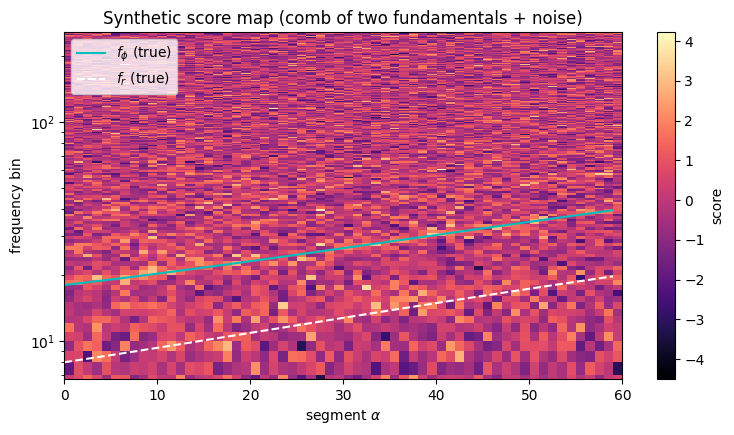

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(np.asarray(score_map).T, origin='lower', aspect='auto',
               cmap='magma', extent=[0, N_seg, 0, N_freq])
ax.plot(seg, f_phi_true, 'c-',  lw=1.5, label=r'$f_\phi$ (true)')
ax.plot(seg, f_r_true,   'w--', lw=1.5, label=r'$f_r$ (true)')
ax.set_yscale('log')
ax.set_xlabel('segment $\\alpha$')
ax.set_ylabel('frequency bin')
ax.set_title('Synthetic score map (comb of two fundamentals + noise)')
ax.legend(loc='upper left')
fig.colorbar(im, ax=ax, label='score'); plt.show()


## Viterbi forward pass 

Given an emission array `emission` of shape `(N_seg, S)` and a log-transition matrix `log_trans` of shape `(S_prev, S_next)` (`0` where a move is allowed, `-inf` where forbidden), the Bellman recursion is defined as 

$$V_\alpha(s) = E_\alpha(s) + \max_{s'} \big[V_{\alpha-1}(s') + \log T(s'\to s)\big].$$

The forward pass stores, for every segment and every state, the argmax predecessor (the backpointer). Backtracking from the best final state then reconstructs the optimal path. The forward pass is the part worth accelerating, so it lives in `lax.scan`. the backtrack is a cheap loop on the host.


In [6]:
def viterbi_forward(emission, log_trans):
    # Hard-max forward pass. Returns (V_last, backpointers).
    def step(V_prev, E_a):
        scores    = V_prev[:, None] + log_trans      # (S_prev, S_next)
        best_prev = jnp.argmax(scores, axis=0)       # (S_next,)
        V         = E_a + jnp.max(scores, axis=0)     # (S_next,)
        return V, best_prev
    V0 = emission[0]   # no transition into segment 0
    V_last, backptrs = lax.scan(step, V0, emission[1:])
    return V_last, backptrs   # backptrs: (N_seg-1, S)

def viterbi_backtrack(V_last, backptrs):
    # Host-side backtrack: integer state path of length N_seg.
    backptrs = np.asarray(backptrs)
    N = backptrs.shape[0] + 1
    path = np.empty(N, dtype=int)
    path[-1] = int(jnp.argmax(V_last))
    for i in range(N - 2, -1, -1):
        path[i] = backptrs[i][path[i + 1]]
    return path

viterbi_forward = jax.jit(viterbi_forward)


## First only consider single-tracks
This is the standard Viterbi tracker as used in CW searches. 

State = a single frequency bin. 
Emission = the raw score map. 
Transitions enforce the following constraints:
- chirp-up 
- continuity**: $0 \le k-k' \le \Delta_{\max}$ (frequency may only rise, by at most a few bins per segment). 

This positive $\dot{f}$ only holds for the fundamental frequency, as negative $n$-modes may cause tracks to ani-chirp. With no single brightest harmonic carrying enough SNR, it latches onto whichever comb line is locally brightest and jumps or wanders between lines. There is no constraint holding the lines together. 


In [7]:
dmax = 6
k = np.arange(N_freq)
dk = k[None, :] - k[:, None]                       # next - prev
allow = (dk >= 0) & (dk <= dmax)
log_trans_1d = jnp.asarray(np.where(allow, 0.0, -np.inf))

V_last_1d, bp_1d = viterbi_forward(score_map, log_trans_1d)
path_1d = viterbi_backtrack(V_last_1d, bp_1d)         # freq bin per segment


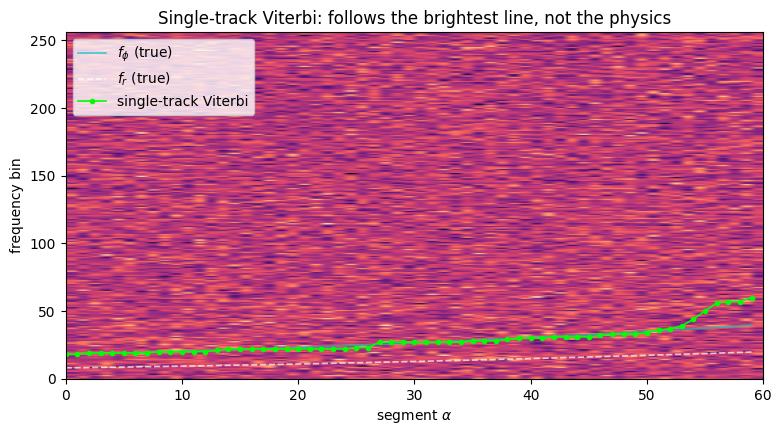

In [8]:
# make plot of random single track Viterbi path
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.imshow(np.asarray(score_map).T, origin='lower', aspect='auto', cmap='magma',
          extent=[0, N_seg, 0, N_freq])
ax.plot(seg, f_phi_true, 'c-',  lw=1.2, alpha=0.7, label=r'$f_\phi$ (true)')
ax.plot(seg, f_r_true,   'w--', lw=1.2, alpha=0.7, label=r'$f_r$ (true)')
ax.plot(seg, path_1d, 'o-', color='lime', ms=3, lw=1.2, label='single-track Viterbi')
ax.set_xlabel('segment $\\alpha$'); ax.set_ylabel('frequency bin')
ax.set_title('Single-track Viterbi: follows the brightest line, not the physics')
ax.legend(loc='upper left'); plt.show()


This is not a useful result for the EMRI search, but can be a test for the different functions that make up the algorithm and a sanity check for the more cmplex multi-voice version. 

## Multi-voice Viterbi with constraints

Now the latent state is theset of fundamentals $(f_\phi, f_r)$ on a coarse grid, and the emission sums over a predefined set of combinations tied to that pair:

$$E_\alpha(f_\phi, f_r) = \sum_{(m,n)\in\mathcal H}\; \texttt{score\_map}\big[\alpha,\; m f_\phi + n f_r\big].$$

The combination indices are independent of $\alpha$, so we precompute them once as a `(S, |H|)` integer gather table (out-of-band members are masked, the toy analogue of $A_\alpha$). Transitions factor per fundamental: each index is non-decreasing, enforcing $\dot f > 0$ chirp and bounded, ensuring the continuity. 

This is the simple Viterbi constrained by the multi-voice decomposition: the combination constraint is what lets a pile of individually-buried lines add up to a confident track.


In [9]:
# create joint grid of (f_phi, f_r) pairs
Gphi = 28
Gr = 24
fphi_grid = np.linspace(15.0, 45.0, Gphi)
fr_grid = np.linspace( 5.0, 24.0, Gr)
S= Gphi * Gr
iphi_of_s = np.repeat(np.arange(Gphi), Gr)           # (S,)
ir_of_s = np.tile(np.arange(Gr), Gphi)             # (S,)
FPHI = fphi_grid[iphi_of_s]                     # (S,)
FR = fr_grid[ir_of_s]                         # (S,)

# create combination table over modes: (S, H) table of integer bins to gather from score map
combo = FPHI[:, None] * m_arr[None, :] + FR[:, None] * n_arr[None, :]   # (S, H)
bins  = np.round(combo).astype(int)
valid = (bins >= 0) & (bins < N_freq)

#clip bins to avoid out-of-bounds indexing
bins_clip = np.clip(bins, 0, N_freq - 1)
bins_clip = jnp.asarray(bins_clip); valid_j = jnp.asarray(valid.astype(np.float64))
print(f"S = {S} joint states, comb table {bins_clip.shape}")


S = 672 joint states, comb table (672, 27)


In [10]:
# define the multi-voice emission function: gather the relevant bins for each join
def multivoice_emission(score_map):
    # gather relevant time-frequency bins for each jouint state
    g = score_map[:, bins_clip]   # (N_seg, S, H)  
    #summation
    return jnp.sum(g * valid_j[None], axis=-1)        # (N_seg, S)

# post-process transition matrix with constraints enforced
bphi, br = 3, 3
dphi = iphi_of_s[None, :] - iphi_of_s[:, None]
dr = ir_of_s[None, :] - ir_of_s[:, None]
allow2 = (dphi >= 0) & (dphi <= bphi) & (dr >= 0) & (dr <= br)
log_trans_2d = jnp.asarray(np.where(allow2, 0.0, -np.inf))

emission_2d = multivoice_emission(score_map)
V_last_2d, bp_2d = viterbi_forward(emission_2d, log_trans_2d)
path_2d = viterbi_backtrack(V_last_2d, bp_2d)         # joint-state index per segment

fphi_rec = fphi_grid[iphi_of_s[path_2d]]
fr_rec   = fr_grid[ir_of_s[path_2d]]


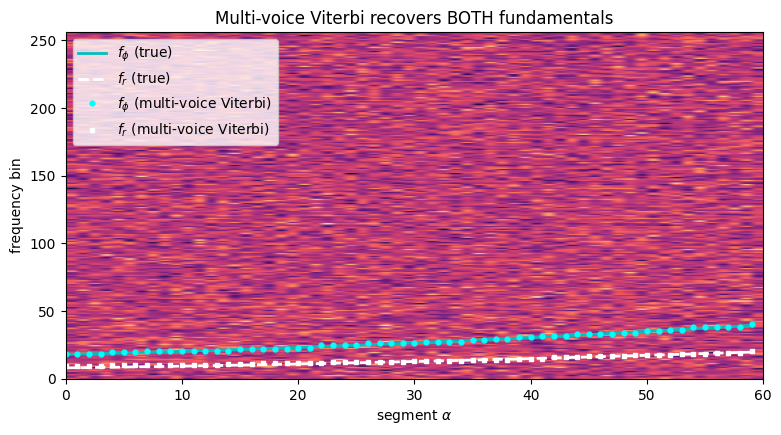

RMS error  f_phi: 0.58 bins   f_r: 0.63 bins (grid spacing 1.11 / 0.83)


In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.imshow(np.asarray(score_map).T, origin='lower', aspect='auto', cmap='magma',
          extent=[0, N_seg, 0, N_freq])

# plot true tracks
ax.plot(seg, f_phi_true, 'c-',  lw=2.0, 
        label=r'$f_\phi$ (true)')
ax.plot(seg, f_r_true, 'w--', lw=2.0, 
        label=r'$f_r$ (true)')

# plot recovered tracks
ax.plot(seg, fphi_rec, 'o', color='cyan',  ms=3.5, 
        label=r'$f_\phi$ (multi-voice Viterbi)')
ax.plot(seg, fr_rec, 's', color='white', ms=3.5, 
        label=r'$f_r$ (multi-voice Viterbi)')


ax.set_xlabel('segment $\\alpha$'); ax.set_ylabel('frequency bin')
ax.set_title('Multi-voice Viterbi recovers BOTH fundamentals')
ax.legend(loc='upper left'); plt.show()

err_phi = np.sqrt(np.mean((fphi_rec - f_phi_true) ** 2))
err_r   = np.sqrt(np.mean((fr_rec   - f_r_true)   ** 2))
print(f"RMS error  f_phi: {err_phi:.2f} bins   f_r: {err_r:.2f} bins "
      f"(grid spacing {fphi_grid[1]-fphi_grid[0]:.2f} / {fr_grid[1]-fr_grid[0]:.2f})")


## Power accumulation along tracks against flattening over noise paths

The current pipeline already lets $\dot f$ vary segment-to-segment (the constant slope is only the *within-bin* slow-chirp approximation) and prunes proposed tracks by continuity. What the Viterbi formulation adds is to make that search *optimal and joint*: the Bellman recursion + backtracking return the single best continuity-respecting path rather than a greedily integrated one, and the joint $(f_\phi,f_r)$ emission couples the two fundamentals through the combinations.

The semi-coherent statistic is the running sum of the emission along a track. The recovered path accumulates power steadily. Other random continuity-respecting tracks wander off the combination lines and average out thanks to the noise properties.

In [13]:
emi_np = np.asarray(emission_2d)
cum_rec = np.cumsum(emi_np[seg, path_2d])

# a few random valid (chirp-up, continuity) tracks for comparison
def random_track():
    s = rng.integers(S)
    out = [s]
    for _ in range(N_seg - 1):
        nxt = np.where(np.asarray(log_trans_2d)[s] == 0.0)[0]
        s = rng.choice(nxt) if len(nxt) else s
        out.append(s)
    return np.array(out)


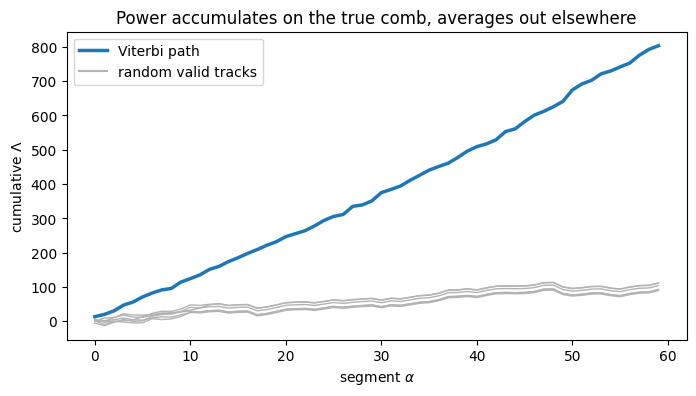

In [14]:

fig, ax = plt.subplots(figsize=(8, 4))
for r in range(6):
    rt = random_track()
    ax.plot(seg, np.cumsum(emi_np[seg, rt]), color='0.7', lw=1)
ax.plot(seg, cum_rec, 'C0-', lw=2.5, label='Viterbi path')
ax.plot([], [], color='0.7', label='random valid tracks')
ax.set_xlabel('segment $\\alpha$'); ax.set_ylabel(r'cumulative $\Lambda$')
ax.set_title('Power accumulates on the true comb, averages out elsewhere')
ax.legend(); plt.show()


## Differentiable Viterbi: backup route

Replacing the hard `max` with a temperature-`logsumexp` makes the forward pass smooth. The useful differentiable knob is not the data but the continuous anchor offset $(\delta_\phi,\delta_r)$ of the two fundamentals: we read the score map at the comb frequencies $m(f_\phi+\delta_\phi)+n(f_r+\delta_r)$ with linear interpolation instead of an integer gather, so the whole `lax.scan` is differentiable in  (\delta_\phi,\delta_r)$. The soft $\log Z$ is then a smooth (non-convex) surface and `jax.grad` flows through. A few gradient steps give a sub-bin refinement of the anchor that the hard Viterbi already localized.

In short: hard Viterbi finds the basin, gradients refine inside it before handing off to parismc. We do not claim the gradient is zero at the true track — the noise realisation displaces the optimum by a fraction of a bin, and that displace optimum is exactly what a refinement step should find. The hard Viterbi remains the primary detector.


grad at (0,0): [-159.04825638  130.5614579 ]  (finite -> differentiable)
refined anchor offset (delta_phi, delta_r) = [-0.085  0.064] bins
soft logZ:  770.24 (start)  ->  779.00 (refined)


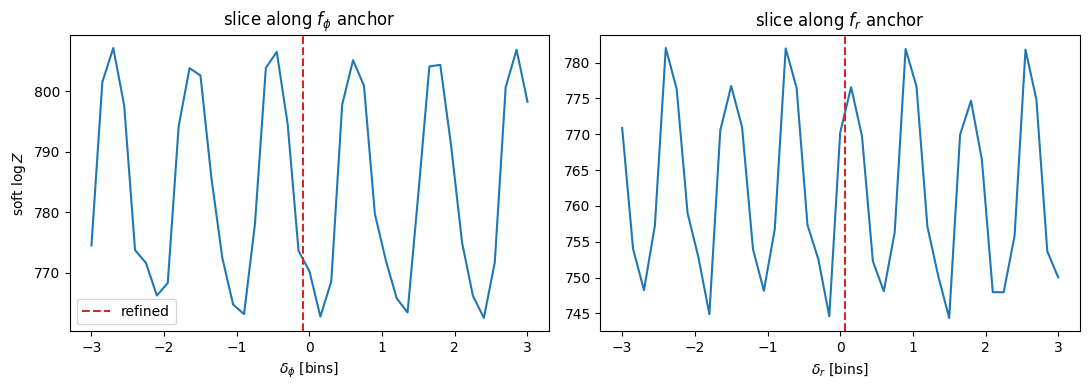

In [15]:
freq_f = jnp.asarray(freq, dtype=jnp.float64)

def emission_smooth(off_phi, off_r):
    # differentiable comb readout: interpolate the map at the *continuous* comb freqs
    cf  = (FPHI + off_phi)[:, None] * m_arr[None] + (FR + off_r)[:, None] * n_arr[None]  # (S,H)
    inb = ((cf >= 0) & (cf < N_freq)).astype(jnp.float64)
    cf_flat = cf.reshape(-1)
    read = jax.vmap(lambda row: jnp.interp(cf_flat, freq_f, row, left=0.0, right=0.0))(score_map)
    return (read.reshape(N_seg, S, -1) * inb[None]).sum(-1)                              # (N_seg,S)

def soft_logZ(off_phi, off_r, tau=2.0):
    e = emission_smooth(off_phi, off_r)
    def step(V, E_a):
        return E_a + (1.0 / tau) * logsumexp(tau * (V[:, None] + log_trans_2d), axis=0), None
    V_last, _ = lax.scan(step, e[0], e[1:])
    return (1.0 / tau) * logsumexp(tau * V_last)

# smooth 1-D slices through the anchor-offset objective
off = np.linspace(-3, 3, 41)
slice_phi = np.array([float(soft_logZ(o, 0.0)) for o in off])
slice_r   = np.array([float(soft_logZ(0.0, o)) for o in off])

# differentiability: gradient flows through the whole forward pass
grad_fn = jax.jit(jax.grad(lambda v: soft_logZ(v[0], v[1])))
print("grad at (0,0):", np.asarray(grad_fn(jnp.array([0.0, 0.0]))), " (finite -> differentiable)")

# a few gradient-ascent steps -> sub-bin refinement of the anchor
v, lr = jnp.array([0.0, 0.0]), 5e-4
logZ0 = float(soft_logZ(v[0], v[1]))
for _ in range(80):
    v = v + lr * grad_fn(v)
print(f"refined anchor offset (delta_phi, delta_r) = {np.asarray(v).round(3)} bins")
print(f"soft logZ:  {logZ0:.2f} (start)  ->  {float(soft_logZ(v[0], v[1])):.2f} (refined)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(off, slice_phi, 'C0-'); ax[0].axvline(float(v[0]), color='C3', ls='--', label='refined')
ax[0].set_xlabel(r'$\delta_\phi$ [bins]'); ax[0].set_ylabel(r'soft $\log Z$')
ax[0].set_title(r'slice along $f_\phi$ anchor'); ax[0].legend()
ax[1].plot(off, slice_r, 'C0-'); ax[1].axvline(float(v[1]), color='C3', ls='--')
ax[1].set_xlabel(r'$\delta_r$ [bins]'); ax[1].set_title(r'slice along $f_r$ anchor')
plt.tight_layout(); plt.show()


## next steps

To turn this into the real thing, we need to:

1. Emission: Replace the synthetic `score_map` with the per-segment semi-coherent statistic from `emrisearch`. We can use `det_stat` for one voice, or the `multi_harmonic_per_mode` combination sum. The gather table `bins_clip` becomes the set of SFT bins $\lfloor (m f_\phi + n f_r) T_{\mathrm{sft}}\rfloor$, and `valid_j` becomes the real $A_\alpha$ band/slow-chirp mask.
2. State: Extend $(f_\phi, f_r)$ to the full $(f_\phi,\dot f_\phi,f_r,\dot f_r)$
3. Pruning: Swap the dense `(S,S)` transition for beam search: keep the top-$B$ states. We can prune at a fixed cadence (e.g. one month of accumulated data). Cost drops to $\mathcal O(N\,B\,|\text{fan-out}|)$. depending on the grid resolution this is a huge saving or rather an optimization step. 

The hard-Viterbi track from this stage is the best-guess $(f_\phi,f_r)(t)$, which we can hand to the inverse problem solver sampler (parismc + fewtrax), whose posterior then feeds into a full PE run with the WDM-basis waveform likelihood.
